In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

mkdir -p failed for path C:\Users\bhuvam\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\bhuvam\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\bhuvam\AppData\Local\Temp\matplotlib-3x9uzqnf because there was an issue with the default path (C:\Users\bhuvam\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import (
    GCNConv,
    global_mean_pool  #There are 14 features(nodes) and all give an output embedding..I have pooled it in single output(final prediciton)
)


c:\Users\bhuvam\OneDrive\Desktop\GNN_health\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**LOAD DATASET**

In [3]:
  df = pd.read_excel('benchmark.xlsx')
  df.head()


,Patient_ID,Age,Gender,Blood_Pressure,Cholesterol,Heart_Rate,BMI,Diabetes,Smoking,Physical_Activity_HoursPerWeek,ECG_Score,Family_History,Glucose,Triglycerides,Stress_Index,Target
0,P0001,68,0,144.9,227.1,123.7,26.5,0,0,3.2,1.18,0,99.4,240.4,5.1,0
1,P0002,58,1,164.2,219.2,145.4,26.0,0,0,0.2,1.16,0,101.5,253.8,6.0,0
2,P0003,44,0,115.7,219.0,169.7,22.6,0,1,1.9,1.79,0,97.8,291.3,5.3,0
3,P0004,72,0,141.3,231.5,128.9,20.9,1,1,3.2,1.46,0,91.3,222.1,7.3,1
4,P0005,37,0,125.5,200.8,186.2,22.3,0,0,2.7,1.65,0,102.5,215.5,4.5,0


**PREPROCESSING**

In [4]:
#Removing Outliers
num_cols = df.drop(columns=["Target"]).select_dtypes(include=['int64','float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("After Outlier Removal:", df.shape)

After Outlier Removal: (966, 16)


In [5]:
X = df.drop(columns=['Target','Patient_ID'])
y = df['Target']

In [6]:
print(df.isnull().sum())

Patient_ID                        0
Age                               0
Gender                            0
Blood_Pressure                    0
Cholesterol                       0
Heart_Rate                        0
BMI                               0
Diabetes                          0
Smoking                           0
Physical_Activity_HoursPerWeek    0
ECG_Score                         0
Family_History                    0
Glucose                           0
Triglycerides                     0
Stress_Index                      0
Target                            0
dtype: int64


In [7]:
#Min-max normalization
scaler = MinMaxScaler()
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)


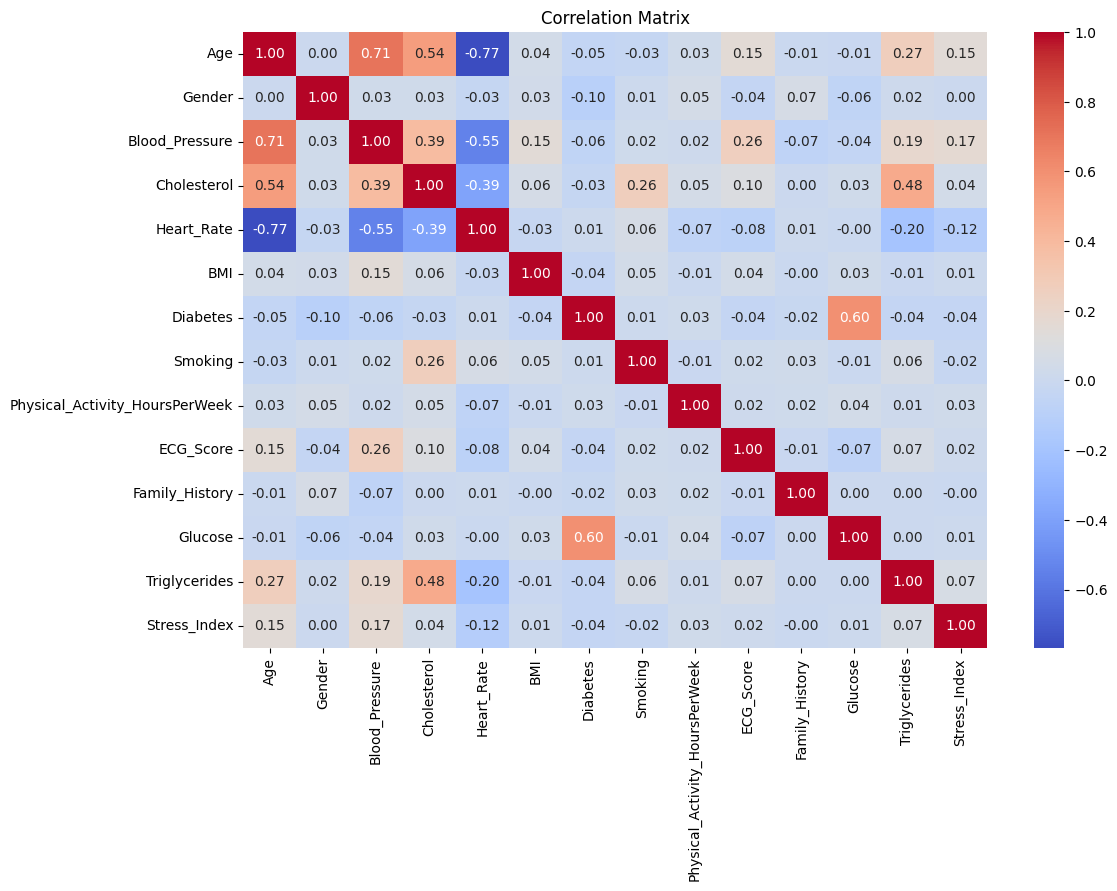

In [8]:
#correlation matrix
import seaborn as sns

corr_matrix = pd.DataFrame(
    X,
    columns=X.columns
).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Train,Test and Validation Split

In [9]:
from sklearn.model_selection import train_test_split

# First split (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Second split (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 676
Validation: 145
Test: 145


**CREATING GRAPH USING NETWORKX**

In [10]:
G = nx.Graph()

for feature in X.columns:
    G.add_node(feature)


threshold = 0.25

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:

            feature_1 = corr_matrix.columns[i]

            feature_2 = corr_matrix.columns[j]

            G.add_edge(
                feature_1,
                feature_2,
                weight=corr_value
            )



print("Number of Nodes :", G.number_of_nodes())
print("Number of Edges :", G.number_of_edges())

print("\nNodes :")

print(list(G.nodes()))

print("\nEdges :")

for edge in G.edges(data=True):

    print(edge)


Number of Nodes : 14
Number of Edges : 11

Nodes :
['Age', 'Gender', 'Blood_Pressure', 'Cholesterol', 'Heart_Rate', 'BMI', 'Diabetes', 'Smoking', 'Physical_Activity_HoursPerWeek', 'ECG_Score', 'Family_History', 'Glucose', 'Triglycerides', 'Stress_Index']

Edges :
('Age', 'Blood_Pressure', {'weight': np.float64(0.7081628265175657)})
('Age', 'Cholesterol', {'weight': np.float64(0.5430885840345365)})
('Age', 'Heart_Rate', {'weight': np.float64(-0.7675794010076596)})
('Age', 'Triglycerides', {'weight': np.float64(0.2676811166659682)})
('Blood_Pressure', 'Cholesterol', {'weight': np.float64(0.3864285972443273)})
('Blood_Pressure', 'Heart_Rate', {'weight': np.float64(-0.5457781379129587)})
('Blood_Pressure', 'ECG_Score', {'weight': np.float64(0.25758385173975823)})
('Cholesterol', 'Heart_Rate', {'weight': np.float64(-0.38954786284392773)})
('Cholesterol', 'Smoking', {'weight': np.float64(0.2639735943403914)})
('Cholesterol', 'Triglycerides', {'weight': np.float64(0.4804156552811338)})
('Diab

In [11]:
node_mapping = {
    node: idx
    for idx, node in enumerate(G.nodes())
}

edge_list = []

for edge in G.edges():

    source = node_mapping[edge[0]]
    target = node_mapping[edge[1]]

    edge_list.append([source, target])
    edge_list.append([target, source])



edge_index = torch.tensor(edge_list,dtype=torch.long).t().contiguous()



In [12]:
def create_graphs(X_data, y_data):

    graph_list = []
    for idx in range(len(X_data)):


        patient_features = X_data.iloc[idx].values

        x = torch.tensor(patient_features,dtype=torch.float).view(-1, 1)
        y = torch.tensor([float(y_data.iloc[idx])],dtype=torch.float)


        graph = Data(
            x=x,
            edge_index=edge_index,
            y=y
        )

        graph_list.append(graph)

    return graph_list


train_graphs = create_graphs(
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

val_graphs = create_graphs(
    X_val.reset_index(drop=True),
    y_val.reset_index(drop=True)
)

test_graphs = create_graphs(
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
)



print("Train Graphs      :", len(train_graphs))

print("Validation Graphs :", len(val_graphs))

print("Test Graphs       :", len(test_graphs))

print("\nSample Train Graph :")

print(train_graphs[0])

Train Graphs      : 676
Validation Graphs : 145
Test Graphs       : 145

Sample Train Graph :
Data(x=[14, 1], edge_index=[2, 22], y=[1])


**Graph Centrality Analysis**

In [13]:
degree_centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame(
    degree_centrality.items(),
    columns=['Feature', 'Centrality']
)

centrality_df = centrality_df.sort_values(
    'Centrality',
    ascending=False
)

print(centrality_df)

                           Feature  Centrality
3                      Cholesterol    0.384615
0                              Age    0.307692
2                   Blood_Pressure    0.307692
4                       Heart_Rate    0.230769
12                   Triglycerides    0.153846
6                         Diabetes    0.076923
11                         Glucose    0.076923
7                          Smoking    0.076923
9                        ECG_Score    0.076923
1                           Gender    0.000000
5                              BMI    0.000000
8   Physical_Activity_HoursPerWeek    0.000000
10                  Family_History    0.000000
13                    Stress_Index    0.000000


**GCN**

**Graph Neural Network Training**

In [14]:
class GCN(torch.nn.Module):

    def __init__(self, input_channels, hidden_channels):

        super().__init__()

        self.conv1 = GCNConv(input_channels,hidden_channels)
        self.conv2 = GCNConv(hidden_channels,hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels,1)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)



        x = F.dropout(
            x,
            p=0.30,
            training=self.training
        )


        x = self.conv2(x, edge_index)

        x = F.relu(x)



        batch = torch.zeros(
            x.size(0),
            dtype=torch.long,
            device=x.device
        )

        # Graph Pooling because [14,hidden_layer] from 14 nodes(feature) make it [1,hidden_layer]

        x = global_mean_pool(x,batch)



        x = self.linear(x)

        x = torch.sigmoid(x)

        return x.view(-1)

In [15]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = GCN(
    input_channels=1,
    hidden_channels=32
).to(device)



optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
criterion = torch.nn.BCELoss()

In [16]:
epochs = 100

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for graph in train_graphs:

        graph = graph.to(device)
        optimizer.zero_grad()
        output = model(graph)

        loss = criterion(output,graph.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_graphs)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100] Loss: 0.3137
Epoch [20/100] Loss: 0.2933
Epoch [30/100] Loss: 0.2699
Epoch [40/100] Loss: 0.2589
Epoch [50/100] Loss: 0.2482
Epoch [60/100] Loss: 0.2389
Epoch [70/100] Loss: 0.2465
Epoch [80/100] Loss: 0.2334
Epoch [90/100] Loss: 0.2415
Epoch [100/100] Loss: 0.2265


**EVALUATION**

In [17]:

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)



model.eval()

all_labels = []
all_predictions = []
all_probabilities = []


with torch.no_grad():

    for graph in test_graphs:

        graph = graph.to(device)

        output = model(graph)

        probability = output.item()

        prediction = 1 if probability > 0.6 else 0



        all_probabilities.append(
            probability
        )

        all_predictions.append(
            prediction
        )

        all_labels.append(
            int(graph.y.item())
        )


accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

mcc = matthews_corrcoef(
    all_labels,
    all_predictions
)


tn, fp, fn, tp = confusion_matrix(
    all_labels,
    all_predictions
).ravel()



specificity = tn / (tn + fp)

error_rate = (
    fp + fn
) / (
    tp + tn + fp + fn
)

false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)




print("\n===================================")
print("FINAL TEST RESULTS")
print("===================================")

print(f"Accuracy                 : {accuracy:.4f}")

print(f"Precision                : {precision:.4f}")

print(f"Recall                   : {recall:.4f}")

print(f"F1 Score                 : {f1:.4f}")

print(f"ROC-AUC                  : {roc_auc:.4f}")

print(f"MCC                      : {mcc:.4f}")

print(f"Specificity              : {specificity:.4f}")

print(f"Error Rate               : {error_rate:.4f}")

print(f"False Positive Rate      : {false_positive_rate:.4f}")

print(f"False Negative Rate      : {false_negative_rate:.4f}")



print("\n===================================")
print("CONFUSION MATRIX")
print("===================================")

print(f"True Positive  (TP) : {tp}")

print(f"True Negative  (TN) : {tn}")

print(f"False Positive (FP) : {fp}")

print(f"False Negative (FN) : {fn}")


FINAL TEST RESULTS
Accuracy                 : 0.9379
Precision                : 0.9412
Recall                   : 0.6667
F1 Score                 : 0.7805
ROC-AUC                  : 0.9446
MCC                      : 0.7606
Specificity              : 0.9917
Error Rate               : 0.0621
False Positive Rate      : 0.0083
False Negative Rate      : 0.3333

CONFUSION MATRIX
True Positive  (TP) : 16
True Negative  (TN) : 120
False Positive (FP) : 1
False Negative (FN) : 8
